# TP 3 — Contours et motifs : solution commentée

Solution complète du [TP 3](./enonce.ipynb).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import patches
from scipy import ndimage as ndi
from skimage import data, draw, feature, filters, transform, util

img = data.camera()
img_f = util.img_as_float(img)

## Exercice 1 — Sobel à la main

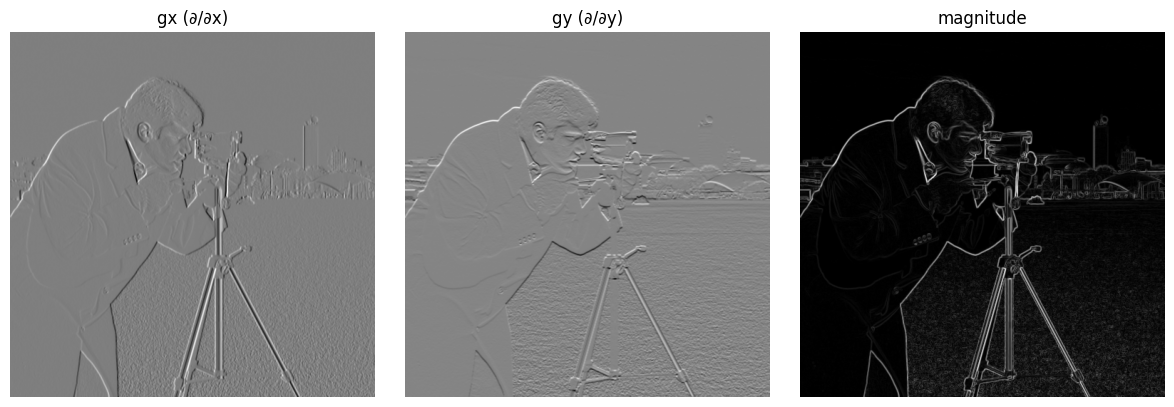

In [2]:
kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
ky = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)

gx = ndi.convolve(img_f, kx)
gy = ndi.convolve(img_f, ky)
mag = np.sqrt(gx**2 + gy**2)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, im, title in zip(axes, [gx, gy, mag], ["gx (∂/∂x)", "gy (∂/∂y)", "magnitude"]):
    ax.imshow(im, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()

## Exercice 2 — Sobel vs Canny

In [ ]:
sob = filters.sobel(img_f)
canny = feature.canny(img_f, sigma=2, low_threshold=0.1, high_threshold=0.2)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img, cmap="gray")
axes[0].set_title("Originale")
axes[1].imshow(sob, cmap="gray")
axes[1].set_title("Sobel (magnitude)")
axes[2].imshow(canny, cmap="gray")
axes[2].set_title("Canny")
for ax in axes:
    ax.axis("off")
plt.tight_layout()

**Discussion** : Sobel renvoie une magnitude continue (épaisse, bruitée) ; Canny applique en plus la suppression des non-maxima (contours d'un pixel d'épaisseur) et le double seuil hystérésis (filtre les contours faibles).

## Exercice 3 — Détection de lignes par Hough

(np.float64(0.0), np.float64(256.0), np.float64(256.0), np.float64(0.0))

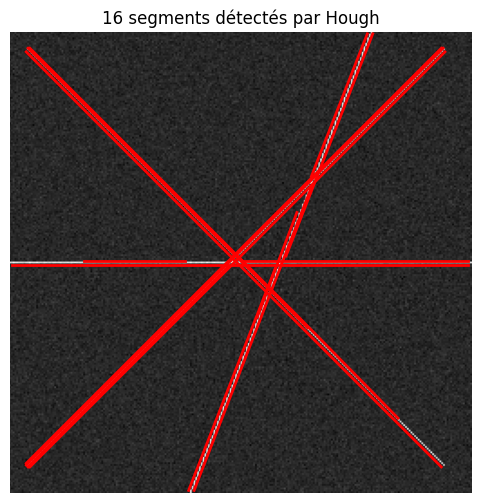

In [8]:
rng = np.random.default_rng(0)
img_lines = np.zeros((256, 256), dtype=np.float32)
for r0, c0, r1, c1 in [
    (10, 10, 240, 240),
    (10, 240, 240, 10),
    (128, 0, 128, 255),
    (0, 200, 255, 100),
]:
    rr, cc = draw.line(r0, c0, r1, c1)
    img_lines[rr, cc] = 1.0
img_lines += rng.normal(0, 0.05, img_lines.shape)

edges = feature.canny(img_lines, sigma=1)
lines = transform.probabilistic_hough_line(edges,
                                           threshold=20,
                                           line_length=50,
                                           line_gap=5)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img_lines, cmap="gray")
for p0, p1 in lines:
    ax.plot((p0[0], p1[0]), (p0[1], p1[1]), "r-", linewidth=2)
ax.set_title(f"{len(lines)} segments détectés par Hough")
ax.set_xlim(0, img_lines.shape[1])
ax.set_ylim(img_lines.shape[0], 0)
ax.axis("off")

**Variante avec `data.checkerboard()`** — au lieu d'une image synthétique, on part d'un damier réel. Les lignes claires entre cases sont des bords parfaitement droits → cas d'école pour Hough.

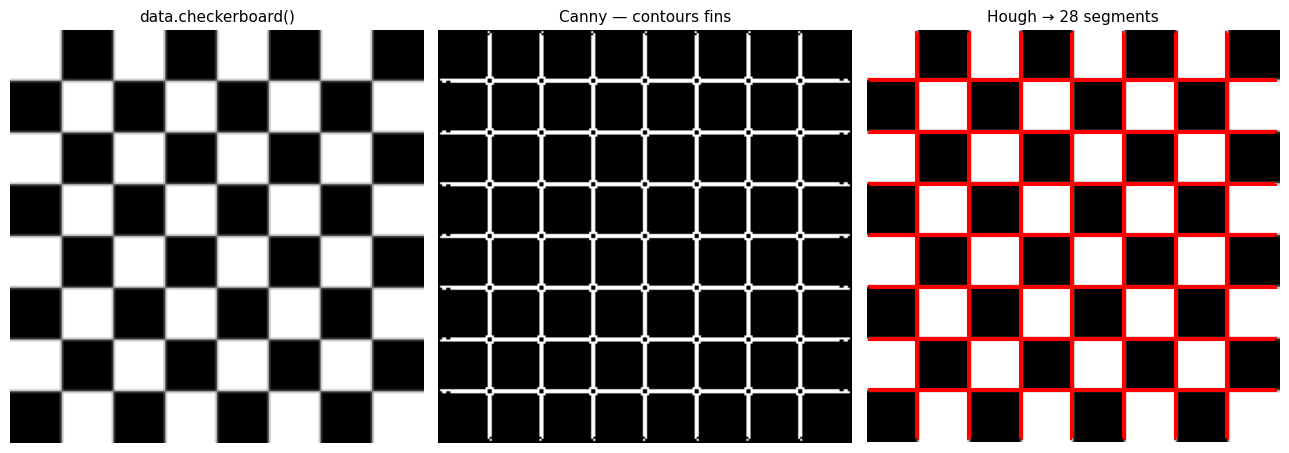

In [9]:
# Variante damier : utiliser data.checkerboard()
checker = data.checkerboard().astype(np.float32) / 255.0

# Canny détecte les bords entre cases (lignes horizontales + verticales)
edges_chk = feature.canny(checker, sigma=1.5)

# Hough probabiliste — on baisse line_length car les côtés de case sont courts
lines_chk = transform.probabilistic_hough_line(
    edges_chk,
    threshold=15,        # seuil bas car peu de pixels par bord
    line_length=20,      # côté d'une case ~25 px
    line_gap=3,
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(checker, cmap="gray")
axes[0].set_title("data.checkerboard()", fontsize=11)
axes[0].axis("off")

axes[1].imshow(edges_chk, cmap="gray")
axes[1].set_title("Canny — contours fins", fontsize=11)
axes[1].axis("off")

axes[2].imshow(checker, cmap="gray")
for p0, p1 in lines_chk:
    axes[2].plot((p0[0], p1[0]), (p0[1], p1[1]), "r-", linewidth=1.5)
axes[2].set_title(f"Hough → {len(lines_chk)} segments", fontsize=11)
axes[2].set_xlim(0, checker.shape[1])
axes[2].set_ylim(checker.shape[0], 0)
axes[2].axis("off")
plt.tight_layout()

In [10]:
len(lines_chk)

28

## Exercice 4 — Template matching

In [ ]:
coins = data.coins()
template = coins[140:200, 220:280]

result = feature.match_template(coins, template)
y, x = np.unravel_index(np.argmax(result), result.shape)
h, w = template.shape

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(template, cmap="gray")
axes[0].set_title("Template")
axes[0].axis("off")
axes[1].imshow(result, cmap="viridis")
axes[1].set_title("Carte de corrélation")
axes[1].axis("off")
axes[2].imshow(coins, cmap="gray")
rect = patches.Rectangle((x, y), w, h, edgecolor="red", facecolor="none", linewidth=2)
axes[2].add_patch(rect)
axes[2].set_title("Position détectée")
axes[2].axis("off")
plt.tight_layout()

In [ ]:
# Bonus : 3 meilleurs matches via peak_local_max.
peaks = feature.peak_local_max(result, min_distance=20, threshold_rel=0.6, num_peaks=3)

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(coins, cmap="gray")
for py, px in peaks:
    ax.add_patch(patches.Rectangle((px, py), w, h, edgecolor="red", facecolor="none", linewidth=2))
ax.set_title(f"{len(peaks)} meilleurs matches")
ax.axis("off")